# HW2 - Classification

## Problem 2

The goal of this homework is to predict whether a flight will arrive at least 15 minutes late. A binary response variable, `DELAYED`, is defined to be 1 when `ARR_DELAY >= 15` and 0 when it's not.

The predictors used are scheduled departure time (`CRS_DEP_TIME`), departure delay (`DEP_DELAY`), taxi-out time (`TAXI_OUT`), scheduled elapsed time (`CRS_ELAPSED_TIME`), and flight distance (`DISTANCE`). Rows with missing values in these variables or the response are removed.

The data are divided into an 80% training set and a 20% test set. The predictors are standardized using the training data before fitting the models (since distance may be in thousands, while dep_delay or taxi_out may be only tens of minutes).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve

In [2]:
#I'm just using the same dataset from hw1
df = pd.read_csv("T_ONTIME_REPORTING.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (544003, 7)


,CRS_DEP_TIME,DEP_DELAY,TAXI_OUT,ARR_DELAY,CANCELLED,CRS_ELAPSED_TIME,DISTANCE
0,2,-10.0,13.0,-38.0,0.0,103.0,413.0
1,2,-8.0,20.0,-28.0,0.0,92.0,264.0
2,2,-2.0,21.0,-23.0,0.0,135.0,552.0
3,2,-1.0,13.0,-21.0,0.0,88.0,296.0
4,2,1.0,16.0,-18.0,0.0,135.0,585.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 544003 entries, 0 to 544002
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CRS_DEP_TIME      544003 non-null  int64  
 1   DEP_DELAY         518774 non-null  float64
 2   TAXI_OUT          518488 non-null  float64
 3   ARR_DELAY         517222 non-null  float64
 4   CANCELLED         544003 non-null  float64
 5   CRS_ELAPSED_TIME  544003 non-null  float64
 6   DISTANCE          544003 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 29.1 MB


In [4]:
#keep the variables used in the classification model
columns = [
    "CRS_DEP_TIME",
    "DEP_DELAY",
    "TAXI_OUT",
    "ARR_DELAY",
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]

data = df[columns].dropna().copy()

# flight is "delayed" if it arrives >= 15 minutes late
data["DELAYED"] = (data["ARR_DELAY"] >= 15).astype(int)

print("Number of observations:", len(data))
print("\nClass counts:")
print(data["DELAYED"].value_counts())

print("\nClass proportions:")
print(data["DELAYED"].value_counts(normalize=True))

data.head()

Number of observations: 517222

Class counts:
DELAYED
0    409747
1    107475
Name: count, dtype: int64

Class proportions:
DELAYED
0    0.792207
1    0.207793
Name: proportion, dtype: float64


,CRS_DEP_TIME,DEP_DELAY,TAXI_OUT,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE,DELAYED
0,2,-10.0,13.0,-38.0,103.0,413.0,0
1,2,-8.0,20.0,-28.0,92.0,264.0,0
2,2,-2.0,21.0,-23.0,135.0,552.0,0
3,2,-1.0,13.0,-21.0,88.0,296.0,0
4,2,1.0,16.0,-18.0,135.0,585.0,0


Of the 517,222 observations used here, ~ 20.8% of flights are classified as delayed and ~79.2% are classified as not delayed. So the response is somewhat imbalanced toward non-delayed flights.

In [5]:
# predictors
features = [
    "CRS_DEP_TIME",
    "DEP_DELAY",
    "TAXI_OUT",
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]

X = data[features]
y = data["DELAYED"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 413777
Test observations: 103445


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

log_error = np.mean(log_predictions != y_test)
log_auc = roc_auc_score(y_test, log_probabilities)

print("Logistic Regression Test Error:", log_error)
print("Logistic Regression AUC:", log_auc)

Logistic Regression Test Error: 0.055788099956498624
Logistic Regression AUC: 0.9643620612992139


In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)
knn_probabilities = knn_model.predict_proba(X_test_scaled)[:, 1]

knn_error = np.mean(knn_predictions != y_test)
knn_auc = roc_auc_score(y_test, knn_probabilities)

print("KNN Test Error:", knn_error)
print("KNN AUC:", knn_auc)

KNN Test Error: 0.06080525883319639
KNN AUC: 0.9395193104345818


In [9]:
k_values = list(range(1, 32, 2))
test_mse = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    
    predictions = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, predictions)
    
    test_mse.append(mse)
    print(f"K = {k:2d}, Test MSE = {mse:.6f}")

K =  1, Test MSE = 0.081657
K =  3, Test MSE = 0.063696
K =  5, Test MSE = 0.060805
K =  7, Test MSE = 0.058640
K =  9, Test MSE = 0.058176
K = 11, Test MSE = 0.058408
K = 13, Test MSE = 0.057905
K = 15, Test MSE = 0.057480
K = 17, Test MSE = 0.057335
K = 19, Test MSE = 0.057422
K = 21, Test MSE = 0.057383
K = 23, Test MSE = 0.057170
K = 25, Test MSE = 0.056977
K = 27, Test MSE = 0.057083
K = 29, Test MSE = 0.056880
K = 31, Test MSE = 0.057083


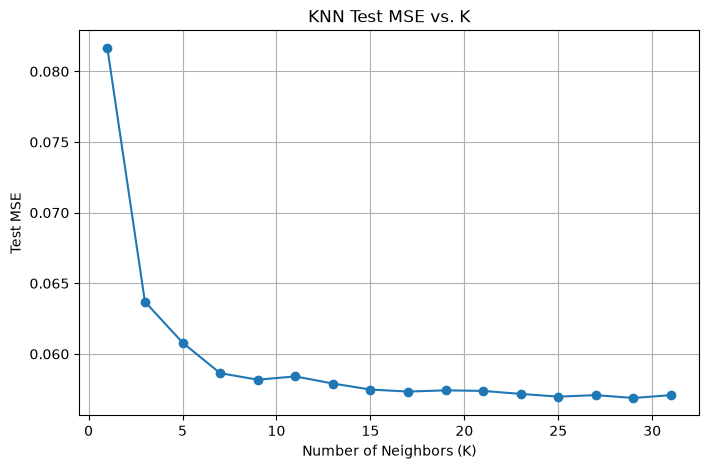

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, test_mse, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test MSE")
plt.title("KNN Test MSE vs. K")
plt.grid(True)
plt.show()

The KNN test MSE decreases greatly as K increases from 1. For K = 1, the test MSE is approximately 0.0817, while by K = 9 it has decreased to approximately 0.0582. After this point, the test MSE changes relatively little as K increases. Among the values tested, K = 29 gives the lowest test MSE, approximately 0.0569.

Since the response and predictions are binary, the test MSE is equal to the misclassification rate here. The relatively large error for small K indicates that using very few neighbors results in a higher-variance classifier, while increasing K produces more stable predictions.

In [11]:
knn_best = KNeighborsClassifier(n_neighbors=29, n_jobs=-1)
knn_best.fit(X_train_scaled, y_train)

knn_best_predictions = knn_best.predict(X_test_scaled)
knn_best_probabilities = knn_best.predict_proba(X_test_scaled)[:, 1]

knn_best_error = np.mean(knn_best_predictions != y_test)
knn_best_auc = roc_auc_score(y_test, knn_best_probabilities)

print("KNN (K=29) Test Error:", knn_best_error)
print("KNN (K=29) AUC:", knn_best_auc)

KNN (K=29) Test Error: 0.05688046788148291
KNN (K=29) AUC: 0.9603256014956443


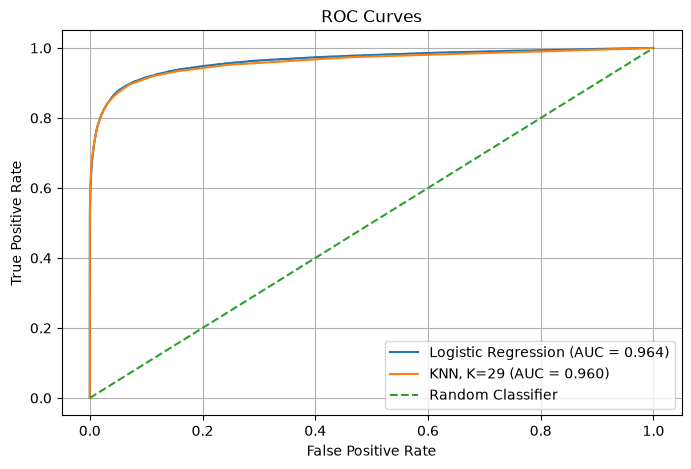

In [12]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_probabilities)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_best_probabilities)

plt.figure(figsize=(8, 5))

plt.plot(log_fpr, log_tpr,
         label=f"Logistic Regression (AUC = {log_auc:.3f})")

plt.plot(knn_fpr, knn_tpr,
         label=f"KNN, K=29 (AUC = {knn_best_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

Logistic regression achieves a test error rate of ~0.0558 and an AUC of ~0.9644. KNN with K = 29 achieves a test error rate of approximately 0.0569 and an AUC of 0.9603. Both classifiers therefore perform similarly on the test data, with logistic regression having a slightly lower test error and slightly higher AUC for this train/test split.

The ROC curves for both classifiers lie well above the diagonal corresponding to random classification, and their AUC values are close to 1. This indicates that both models are effective at distinguishing delayed flights from non-delayed flights across classification thresholds.

The KNN results also demonstrate the importance of the choice of K. Very small values of K give substantially larger test error, while the error decreases and then levels off as K increases.

## Problem 3

### Discriminant Function and Posterior Probability

From Bayes' theorem, the posterior probability that an observation $x$ belongs to class $k$ is

$$
P(Y=k \mid X=x)
=
\frac{\pi_k f_k(x)}
{\sum_{l=1}^{K} \pi_l f_l(x)},
$$

where $\pi_k = P(Y=k)$ is the prior probability of class $k$ and $f_k(x)$ is the density of $X$ for class $k$.

For a fixed observation $x$, the denominator is the same for every class $k$. So,

$$
\underset{k}{\operatorname{argmax}}\;P(Y=k \mid X=x)
=
\underset{k}{\operatorname{argmax}}\;\pi_k f_k(x).
$$

Because the logarithm is a strictly increasing function, taking the logarithm does not change which class maximizes the expression. Thus,

$$
\underset{k}{\operatorname{argmax}}\;\pi_k f_k(x)
=
\underset{k}{\operatorname{argmax}}\;
\left[\log f_k(x)+\log\pi_k\right].
$$

We can therefore define a discriminant score as

$$
\delta_k(x)=\log f_k(x)+\log\pi_k.
$$

(In a couple lines I'll explain why we can do this) It follows that

$$
\underset{k}{\operatorname{argmax}}\;\delta_k(x)
=
\underset{k}{\operatorname{argmax}}\;P(Y=k \mid X=x).
$$

For LDA with $p=1$, assume that the distribution within each class is Gaussian with mean $\mu_k$ and a common variance $\sigma^2$:

$$
f_k(x)
=
\frac{1}{\sqrt{2\pi}\sigma}
\exp\left(
-\frac{(x-\mu_k)^2}{2\sigma^2}
\right).
$$

Substituting this into the discriminant score gives

$$
\delta_k(x)
=
-\log(\sqrt{2\pi}\sigma)
-\frac{(x-\mu_k)^2}{2\sigma^2}
+\log\pi_k.
$$

Expanding the squared term,

$$
\delta_k(x)
=
-\log(\sqrt{2\pi}\sigma)
-\frac{x^2}{2\sigma^2}
+\frac{x\mu_k}{\sigma^2}
-\frac{\mu_k^2}{2\sigma^2}
+\log\pi_k.
$$

The first two terms are independent of $k$, so they do not affect which class maximizes the discriminant. They can therefore be removed, giving the LDA discriminant function

$$
\delta_k(x)
=
\frac{x\mu_k}{\sigma^2}
-\frac{\mu_k^2}{2\sigma^2}
+\log\pi_k.
$$

Thus, maximizing the LDA discriminant function is equivalent to maximizing the posterior probability.

### Removing the Constant Class Variance Assumption

Now suppose that each class has its own variance $\sigma_k^2$ rather than sharing a common variance. Then

$$
f_k(x)
=
\frac{1}{\sqrt{2\pi}\sigma_k}
\exp\left(
-\frac{(x-\mu_k)^2}{2\sigma_k^2}
\right).
$$

Using the same discriminant score,

$$
\delta_k(x)
=
\log f_k(x)+\log\pi_k,
$$

we obtain

$$
\delta_k(x)
=
-\log(\sqrt{2\pi}\sigma_k)
-\frac{(x-\mu_k)^2}{2\sigma_k^2}
+\log\pi_k.
$$

Expanding the squared term gives

$$
\delta_k(x)
=
-\log(\sqrt{2\pi}\sigma_k)
-\frac{x^2}{2\sigma_k^2}
+\frac{x\mu_k}{\sigma_k^2}
-\frac{\mu_k^2}{2\sigma_k^2}
+\log\pi_k.
$$

The term $-\frac{1}{2}\log(2\pi)$ is independent of the class and can be removed. Therefore, the discriminant can be written as

$$
\delta_k(x)
=
-\frac{x^2}{2\sigma_k^2}
+\frac{x\mu_k}{\sigma_k^2}
-\frac{\mu_k^2}{2\sigma_k^2}
-\log\sigma_k
+\log\pi_k.
$$

Unlike the LDA case, the coefficient of $x^2$ now depends on the class through $\sigma_k^2$. Therefore, the $x^2$ term cannot be removed when comparing classes. The discriminant has the form

$$
\delta_k(x)=A_kx^2+B_kx+C_k,
$$

so the discriminant function is quadratic in $x$.